#-------------------------------------------------------------------------------------------------------------
Project:        Computational Intelligence Coursework C
Description:    Main script containing the filtering, spike detection, dimensionality reduction and neural 
                network to classify neural spikes.
#-------------------------------------------------------------------------------------------------------------

In [1]:
# Display figures such that zoom is possible!
%matplotlib ipympl

# General libraries to import
import scipy.io as spio
import numpy as np
import scipy.special 
import matplotlib.pyplot as plt
# import seaborn as sns
# sns.set_theme(style="whitegrid")

# filter libraries
from scipy.signal import butter,filtfilt

# spike detection libraries
from scipy.signal import find_peaks

# PCA libraries
from sklearn.decomposition import PCA

# classifier
import my_nn_class as nn
from tensorflow.keras.utils import to_categorical

# confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# save
from scipy.io import savemat

# Preprocessing Data Functions

In [2]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
        """ Filter data
        
        Bandpass filter input data using a Butterworth filter
        
        :param: data - numpy array of input data
        :param: lowcut - lower cutoff frequency of bandpass filter
        :param: highcut - upper cutoff frequency of bandpass filter
        
        :return: filt_data - numpy array of filtered input data
        """
        
        # Calculate low and high cutoff frequencies as a fraction of the nyquist frequency 
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq

        # Calculate coefficients for butterworth bandpass filter
        b, a = butter(order, [low, high], analog=False, btype='band')

        # Use filtfilt() to performs zero-phase digital filtering by processing the input data 
        # x in both the forward and reverse directions. This results in Zero phase distortion, 
        # A filter transfer function equal to the squared magnitude of the original filter 
        # transfer function and A filter order that is double the order of the filter specified 
        # by b and a.
        filt_data = filtfilt(b, a, data)

        return filt_data

In [3]:
# function to normalise data
def NormaliseData(inData):
    """ Normalise array

    Normalise input and target data (min-max normalisation)

    :param: inData - numpy array of input data

    :return: normData - numpy array of normalised input data
    """

    inData = inData.astype("float32") / 255

    max_val = max(inData)
    min_val = min(inData)
    range_val = max_val - min_val 

    normData = inData.copy()
    j = 0
    for i in inData:
        normData[j] = (i - min_val)/range_val 

    return normData

# Load Data

D1: This is a low noise recording that is fully labelled, it has both Index and Class vectors that are
correct. You should use this for training your classifier. <br>
D2: This is a low noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D3: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>
D4: This is a high noise recording that does not contain labels (i.e., it only contains the d vector). <br>

Text(0.5, 1.0, 'Filtered D1')

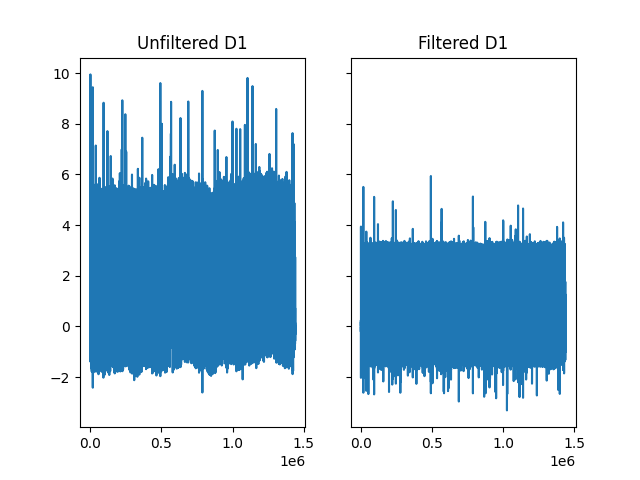

In [4]:
mat = spio.loadmat('D1.mat', squeeze_me=True)
d1 = mat['d'] # Raw time domain recording (1440000 samples), 25 kHz sampling frequency.
Index1 = mat['Index'] # The location in the recording (in samples) of the start of each spike.
Class1 = mat['Class'] # The class (1, 2, 3, 4 or 5), i.e the type of neuron that generated each spike.

# Filter - better for peak detection (from literature).
fs = 25000      # sample rate, Hz
order = 1       
lowcut = 300    # 300, 250, 300
highcut  = 2500 # 3000, 4050, 2600

# Filter
d1_f = butter_bandpass_filter(d1, lowcut, highcut, fs, order)

# plot
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.plot(d1)
ax1.set_title('Unfiltered D1')
ax2.plot(d1_f, zorder=-1)
ax2.set_title('Filtered D1')

Text(0.5, 1.0, 'Filtered D2')

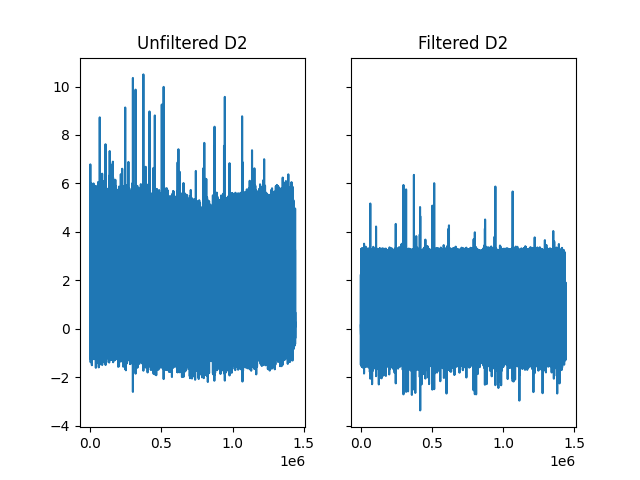

In [5]:
# Load dataset D2 into Python
mat = spio.loadmat('D2.mat', squeeze_me=True)
d2 = mat['d']

# Filter
d2_f = butter_bandpass_filter(d2, lowcut, highcut, fs, order)

# plot
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.plot(d2)
ax1.set_title('Unfiltered D2')
ax2.plot(d2_f, zorder=-1)
ax2.set_title('Filtered D2')

Text(0.5, 1.0, 'Filtered D3')

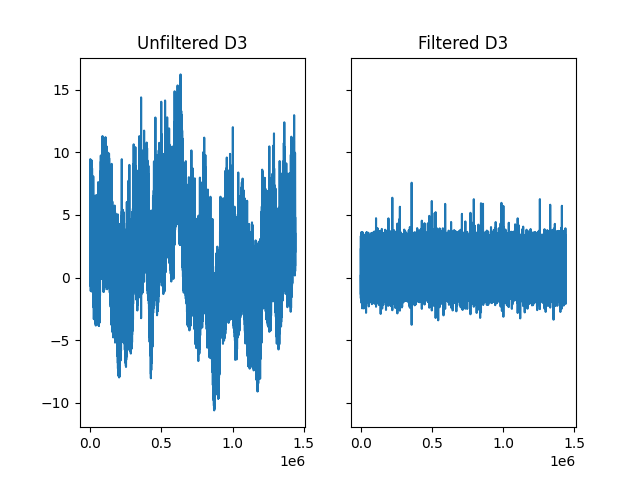

In [6]:
# Load dataset D3 into Python
mat = spio.loadmat('D3.mat', squeeze_me=True)
d3 = mat['d']

# Filter
d3_f = butter_bandpass_filter(d3, lowcut, highcut, fs, order)

# plot
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.plot(d3)
ax1.set_title('Unfiltered D3')
ax2.plot(d3_f, zorder=-1)
ax2.set_title('Filtered D3')

Text(0.5, 1.0, 'Filtered D4')

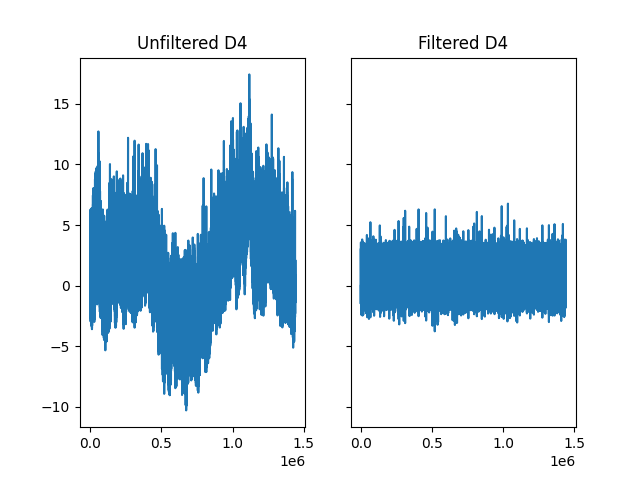

In [7]:
# Load dataset D2 into Python
mat = spio.loadmat('D4.mat', squeeze_me=True)
d4 = mat['d']

# filter
d4_f = butter_bandpass_filter(d4, lowcut, highcut, fs, order)

# plot
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.plot(d4)
ax1.set_title('Unfiltered D4')
ax2.plot(d4_f, zorder=-1)
ax2.set_title('Filtered D4')

# Spike Detection

In [8]:
# calculate standard deviation of signal using Donoho's estimation
std = (np.median(abs(d1)/0.6745))

# spike detection threshold
ts = std*3 # some papers use 5*std

peaks1, _ = find_peaks(d1, prominence=1.6, height = ts)

In [9]:
# calculate standard deviation of signal using Donoho's estimation
std2 = (np.median(abs(d2)/0.6745))

# spike detection threshold
ts2 = std2*3 # some papers use 5*std

peaks2, _ = find_peaks(d2, prominence=1.6, height=ts2) 

Index2 = peaks2.copy()
for i in range(len(Index2)):
    Index2[i] = Index2[i] - 10
 

In [10]:
# calculate standard deviation of signal using Donoho's estimation
std3 = (np.median(abs(d3_f)/0.6745))

# spike detection threshold
ts3 = std3*3 # some papers use 5*std

peaks3, _ = find_peaks(d3_f, prominence=1.6, height=ts3)

Index3 = peaks3.copy()
for i in range(len(Index3)):
    Index3[i] = Index3[i] - 10
 

In [11]:
# calculate standard deviation of signal using Donoho's estimation
std4 = (np.median(abs(d4_f)/0.6745))

# spike detection threshold
ts4 = std4*3 # some papers use 5*std

peaks4, _ = find_peaks(d4_f, prominence=1.6, height=ts4) 

Index4 = peaks4.copy()
for i in range(len(Index4)):
    Index4[i] = Index4[i] - 10


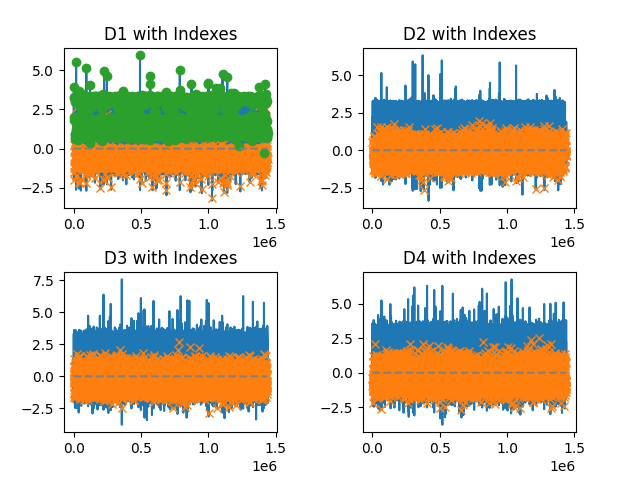

In [12]:
plt.figure(4)
plt.subplot(2, 2, 1)
plt.plot(d1_f)
plt.plot(Index1, d1_f[Index1], "x")
plt.plot(peaks1, d1_f[peaks1], "o")
plt.plot(np.zeros_like(d1_f), "--", color="gray")
plt.title('D1 with Indexes')

plt.subplot(2, 2, 2)
plt.plot(d2_f)
plt.plot(Index2, d2_f[Index2], "x")
plt.plot(np.zeros_like(d2_f), "--", color="gray")
plt.title('D2 with Indexes')

plt.subplot(2, 2, 3)
plt.plot(d3_f)
plt.plot(Index3, d3_f[Index3], "x")
plt.plot(np.zeros_like(d3_f), "--", color="gray")
plt.title('D3 with Indexes')

plt.subplot(2, 2, 4)
plt.plot(d4_f)
plt.plot(Index4, d4_f[Index4], "x")
plt.plot(np.zeros_like(d4_f), "--", color="gray")
plt.title('D4 with Indexes')

# set the spacing between subplots
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)
plt.show()

In [13]:
# Define period of each spike
n_2ms = int((25e3) * 2.5e-3) # int((25e3)/downsample_factor * 2e-3)
n = int((25e3) * 0.5e-3) 

# Sort index and class
Index1_sorted, Class1_sorted = zip(*sorted(zip(Index1, Class1)))
Index2_sorted = sorted(Index2)
Index3_sorted = sorted(Index3)
Index4_sorted = sorted(Index4)

# Normalise data for classifier
d1_n = NormaliseData(d1_f)
d2_n = NormaliseData(d2_f)
d3_n = NormaliseData(d3_f)
d4_n = NormaliseData(d4_f)

# Storage for data to be classified
spike = np.zeros([n_2ms+n,len(Index1)])
spike2 = np.zeros([n_2ms+n,len(Index2)])
spike3 = np.zeros([n_2ms+n,len(Index3)])
spike4 = np.zeros([n_2ms+n,len(Index4)])

# --- Input data to be classified -----------------------------------
# Set up arrays for neural network d1
k = 0
for i in range(n,len(d1)-n_2ms):
    if k < len(Index1_sorted) and i == Index1_sorted[k]:
        spike[:,k] = d1_n[i-n:i+n_2ms]
        k = k + 1

# Set up arrays for neural network d2
k = 0
for i in range(n,len(d2)-n_2ms):
    if k < len(Index2_sorted) and i == Index2_sorted[k]:
        spike2[:,k] = d2_n[i-n:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d3
k = 0
for i in range(n,len(d3_f)-n_2ms):
    if k < len(Index3_sorted) and i == Index3_sorted[k]:
        spike3[:,k] = d3_n[i-n:i+n_2ms]
        k = k + 1 

# Set up arrays for neural network d4
k = 0
for i in range(n,len(d4_f)-n_2ms):
    if k < len(Index4_sorted) and i == Index4_sorted[k]:
        spike4[:,k] = d4_n[i-n:i+n_2ms]
        k = k + 1 

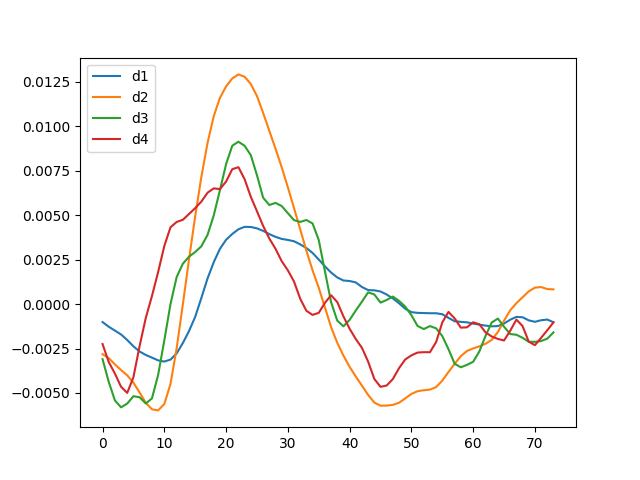

In [14]:
plt.figure(5)
plt.cla()
plt.clf()
plt.plot(spike[:,11])
plt.plot(spike2[:,2])
plt.plot(spike3[:,2])
plt.plot(spike4[:,2])
plt.legend(['d1', 'd2', 'd3', 'd4'], loc='upper left') #, 'd3', 'd4'
plt.show() 

# Dimension Reduction

In [15]:
# train-test split
x = len(spike[0])
d1_spikes_train = spike[:,0:int(x*0.9)].transpose()
d1_spikes_test = spike[:,int(x*0.9):].transpose()
class1_train = Class1_sorted[0:int(x*0.9)]
class1_test = Class1_sorted[int(x*0.9):]

# correct format of data
d2_spikes_test = spike2.transpose()
d3_spikes_test = spike3.transpose()
d4_spikes_test = spike4.transpose()

# Print inputs to neural network
print("D1 No. of Train Spikes: ", d1_spikes_train.shape)
print("D1 No. of Test Spikes: ", d1_spikes_test.shape)
print("D2 No. of Test Spikes: ", d2_spikes_test.shape)
print("D3 No. of Test Spikes: ", d3_spikes_test.shape)
print("D4 No. of Test Spikes: ", d4_spikes_test.shape)

D1 No. of Train Spikes:  (2477, 74)
D1 No. of Test Spikes:  (276, 74)
D2 No. of Test Spikes:  (2322, 74)
D3 No. of Test Spikes:  (3381, 74)
D4 No. of Test Spikes:  (3626, 74)


Total Variance Explained:  0.8691689118177918


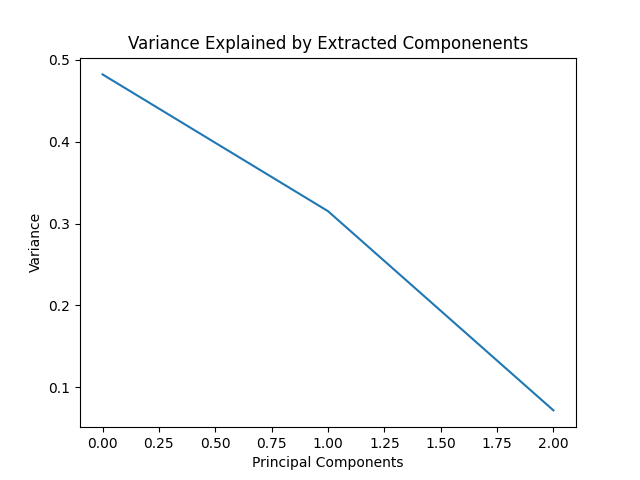

In [16]:
# Select number of components to extract
pca_num = 3
pca = PCA(n_components = pca_num)

# Fit to the training data
pca.fit(d1_spikes_train)

# Determine amount of variance explained by components
print("Total Variance Explained: ", np.sum(pca.explained_variance_ratio_))

# Plot the explained variance
plt.figure(6)
plt.plot(pca.explained_variance_ratio_)
plt.title('Variance Explained by Extracted Componenents')
plt.ylabel('Variance')
plt.xlabel('Principal Components')
plt.show()

# Classifier

In [17]:
# Extract the principal components from the training data
train_ext = pca.fit_transform(d1_spikes_train)

# Transform the test data using the same components
test_ext = pca.transform(d1_spikes_test)
test_ext2 = pca.transform(d2_spikes_test)
test_ext3 = pca.transform(d3_spikes_test)
test_ext4 = pca.transform(d4_spikes_test)

Feature shape: (3,)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                256       
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout (Dropout)            (None, 32)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 6)                 198       
Total params: 2,534
Trainable params: 2,534
Non-trainable params: 0
_________________________________________________________________
Epoch 1/500
31/31 [==============================] - 1s 11ms/step - loss: 2.1013 - accuracy: 0.3867 - val_loss: 2.0690 - val_accuracy: 0.3569
Epoch 2/500
31/31 [==============================] - 0s 4ms/step - loss: 2.0350 - accuracy

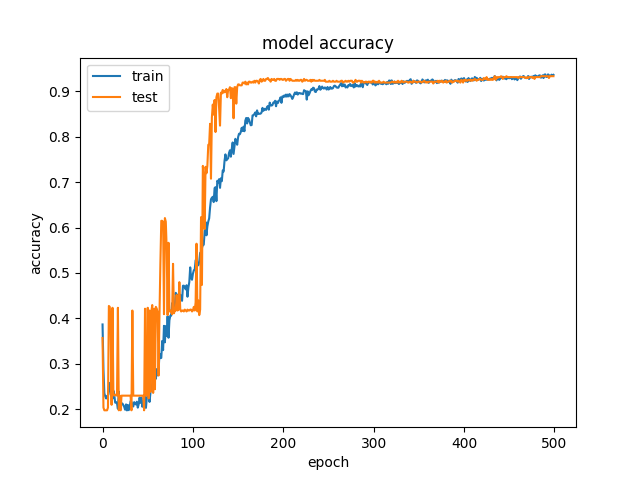

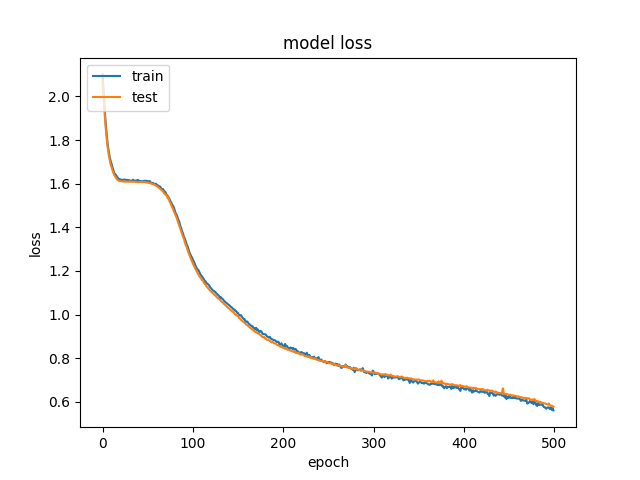

9/9 [==============================] - 0s 1ms/step - loss: 0.7010 - accuracy: 0.9058
Test loss: 0.7009506821632385
Test accuracy: 0.9057971239089966


In [18]:
# Configuration options 
feature_vector_length = pca_num
num_classes = 6

# Reshape the data 
X_train = train_ext 
X_test = test_ext 

# Convert target classes to categorical ones
Y_train = to_categorical(class1_train, num_classes)
Y_test = to_categorical(class1_test, num_classes)

# Set the input shape
input_shape = (feature_vector_length,)
print(f'Feature shape: {input_shape}')

# define the input shape for the neural network and initialise the class
nn_mlp = nn.NeuralNetwork(input_shape, num_classes)

# Train the model
nn_mlp.TrainNN(X_train, Y_train, batch_size = 64, epochs = 500) 

# Test the model
[ScoreMLP, predictionsMLP] = nn_mlp.ValNN(X_test, Y_test)
print("Test loss:", ScoreMLP[0])
print("Test accuracy:", ScoreMLP[1])

Number of 1s predicted:  577
Number of 2s predicted:  564
Number of 3s predicted:  550
Number of 4s predicted:  544
Number of 5s predicted:  518


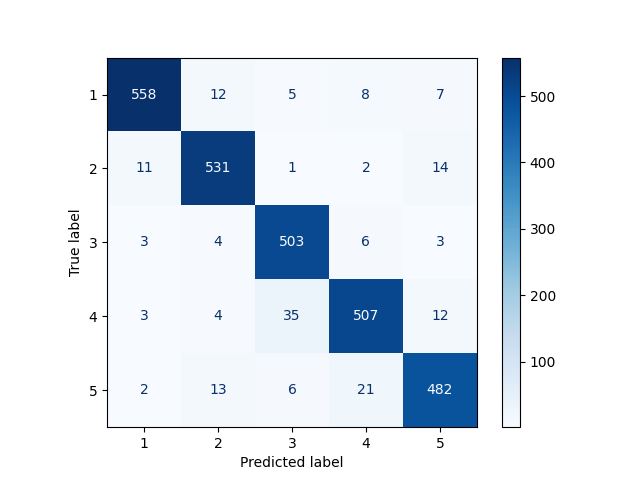

In [19]:
class1_in = pca.fit_transform(spike.transpose())

Class1_pred = nn_mlp.TestNN(class1_in)

cm = confusion_matrix(Class1_sorted, Class1_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])

plt.figure(8)
disp = disp.plot(cmap=plt.cm.Blues,values_format='g')
plt.show()

In [20]:
# # Test the model after training
Class2 = nn_mlp.TestNN(test_ext2)

Number of 1s predicted:  496
Number of 2s predicted:  476
Number of 3s predicted:  462
Number of 4s predicted:  447
Number of 5s predicted:  441


In [21]:
col = ['k', 'r', 'b', 'c', 'g']

# plt.figure(9)
# plt.cla()
# plt.clf()
# for i in range(len(spike[1,:])):
#     plt.plot(spike[:,i], c=col[Class1_sorted[i]-1])
# plt.show() 

In [22]:
# # Plot the explained variance
# plt.figure(9)
# plt.cla()
# plt.clf()
# for i in range(len(train_ext[:,1])):
#     plt.scatter(train_ext[i,0], train_ext[i,1], c=col[Class1_sorted[i]-1])
# plt.show()

In [23]:
# plt.figure(10)
# plt.cla()
# plt.clf()
# for i in range(len(spike2[1,:])):
#     plt.plot(spike2[:,i], c=col[Class2[i]-1])
# plt.show() 

In [24]:
# Plot the explained variance
# plt.figure(10)
# plt.cla()
# plt.clf()
# for i in range(len(test_ext2[:,1])):
#     plt.scatter(test_ext2[i,0], test_ext2[i,1], c=col[Class2[i]-1])
# plt.show()

In [34]:
# mdic = {"d": d2, "Index": Index2_sorted, "Class": Class2 }
# savemat("D2_submit.mat", mdic)

In [26]:
# class3_out = model.predict(d3_spikes_test)
Class3 = nn_mlp.TestNN(test_ext3)      

Number of 1s predicted:  694
Number of 2s predicted:  710
Number of 3s predicted:  624
Number of 4s predicted:  738
Number of 5s predicted:  615


In [27]:
# plt.figure(11)
# plt.cla()
# plt.clf()
# for i in range(len(spike3[1,:])):
#     plt.plot(spike3[:,i], c=col[Class3[i]-1])
# plt.show() 

In [28]:
# Plot the explained variance
# plt.figure(11)
# plt.cla()
# plt.clf()
# for i in range(len(test_ext3[:,1])):
#     plt.scatter(test_ext3[i,0], test_ext3[i,1], c=col[Class3[i]-1])
# plt.show()

In [35]:
# mdic = {"d": d3, "Index": Index3_sorted, "Class": Class3 }
# savemat("D3_submit.mat", mdic)

In [30]:
# class4_out = model.predict(d4_spikes_test)
Class4 = nn_mlp.TestNN(test_ext4)   

Number of 1s predicted:  735
Number of 2s predicted:  749
Number of 3s predicted:  657
Number of 4s predicted:  781
Number of 5s predicted:  704


In [31]:
# plt.figure(12)
# plt.cla()
# plt.clf()
# for i in range(len(spike4[1,:])):
#     plt.plot(spike4[:,i], c=col[Class4[i]-1])
# plt.show() 

In [32]:
# Plot the explained variance
# plt.figure(12)
# plt.cla()
# plt.clf()
# for i in range(len(test_ext4[:,1])):
#     plt.scatter(test_ext4[i,0], test_ext4[i,1], c=col[Class4[i]-1])
# plt.show()

In [36]:
# mdic = {"d": d4, "Index": Index4_sorted, "Class": Class4 }
# savemat("D4_submit.mat", mdic)